In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA GeForce RTX 3050 Laptop GPU


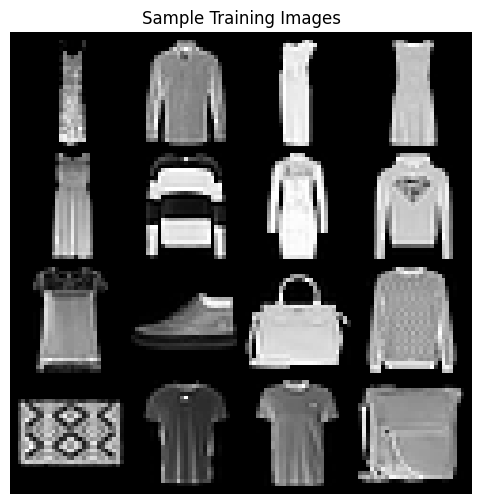

In [2]:
# 2 
BATCH_SIZE = 128
LATENT_DIM = 20

# Transform for VAE: [0, 1]
transform_vae = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform_vae, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform_vae, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Visualization
images, _ = next(iter(train_loader))
grid = torchvision.utils.make_grid(images[:16], nrow=4)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title("Sample Training Images")
plt.show()

In [4]:
# 3 
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(ConvVAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logvar = nn.Linear(3136, latent_dim)
        
        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 3136)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(self.decoder_input(z))
        return x_recon, mu, logvar

vae = ConvVAE(latent_dim=LATENT_DIM).to(device)

In [10]:
#4 
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

# Updated Loss Function to return components
def vae_loss_function(recon_x, x, mu, logvar):
    # 1. Reconstruction (BCE)
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

In [11]:
num_epochs = 20
train_losses = []
recon_losses = []
kld_losses = []

print("Starting VAE Training...")

for epoch in range(num_epochs):
    vae.train()
    total_loss = 0
    total_recon = 0
    total_kld = 0
    
    # Iterate over batch
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        # Forward pass
        recon_batch, mu, logvar = vae(data)
        
        # Calculate loss components
        loss, bce, kld = vae_loss_function(recon_batch, data, mu, logvar)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        total_recon += bce.item()
        total_kld += kld.item()
        
    # Average metrics per sample
    n_samples = len(train_loader.dataset)
    avg_loss = total_loss / n_samples
    avg_recon = total_recon / n_samples
    avg_kld = total_kld / n_samples
    
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kld_losses.append(avg_kld)
    
    # Print detailed metrics
    print(f'Epoch [{epoch+1}/{num_epochs}] | '
          f'Total Loss: {avg_loss:.4f} | '
          f'Recon Loss: {avg_recon:.4f} | '
          f'KL Div: {avg_kld:.4f}')

print("Training Complete!")

Starting VAE Training...
Epoch [1/20] | Total Loss: 247.6478 | Recon Loss: 228.5966 | KL Div: 19.0512
Epoch [2/20] | Total Loss: 246.2788 | Recon Loss: 227.3867 | KL Div: 18.8921
Epoch [3/20] | Total Loss: 245.3329 | Recon Loss: 226.5641 | KL Div: 18.7688
Epoch [4/20] | Total Loss: 244.6326 | Recon Loss: 225.9408 | KL Div: 18.6918
Epoch [5/20] | Total Loss: 244.0133 | Recon Loss: 225.4261 | KL Div: 18.5872
Epoch [6/20] | Total Loss: 243.5367 | Recon Loss: 225.0362 | KL Div: 18.5005
Epoch [7/20] | Total Loss: 243.1581 | Recon Loss: 224.7260 | KL Div: 18.4320
Epoch [8/20] | Total Loss: 242.8398 | Recon Loss: 224.4786 | KL Div: 18.3612
Epoch [9/20] | Total Loss: 242.4955 | Recon Loss: 224.1840 | KL Div: 18.3115
Epoch [10/20] | Total Loss: 242.2598 | Recon Loss: 224.0276 | KL Div: 18.2322
Epoch [11/20] | Total Loss: 242.0566 | Recon Loss: 223.8360 | KL Div: 18.2206
Epoch [12/20] | Total Loss: 241.8071 | Recon Loss: 223.6771 | KL Div: 18.1300
Epoch [13/20] | Total Loss: 241.6938 | Recon Los

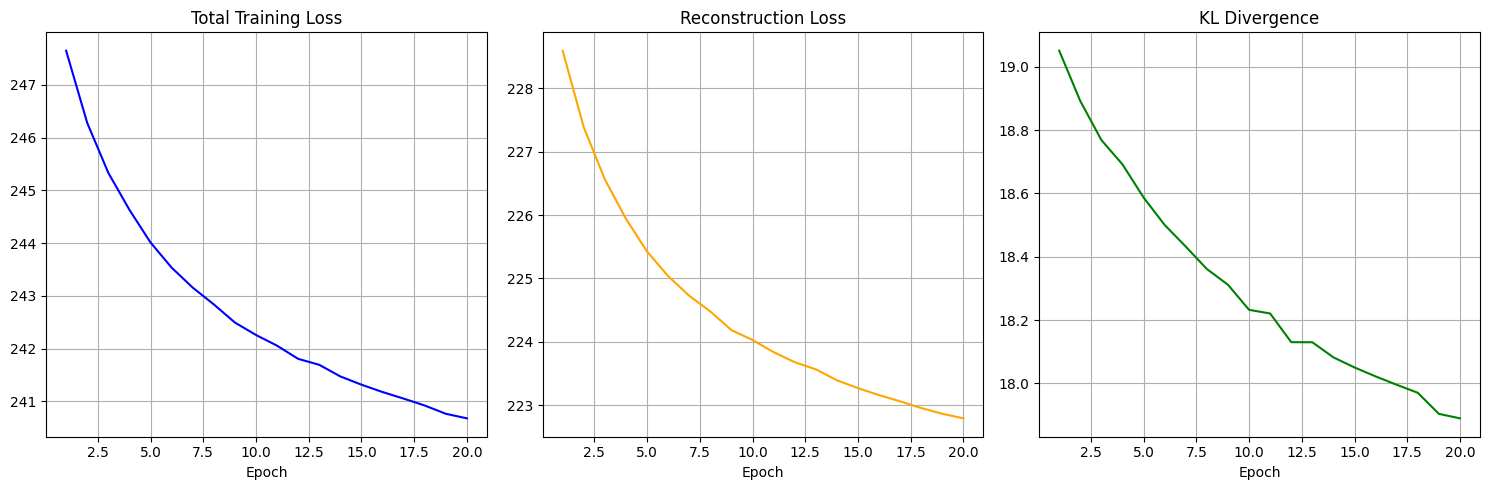

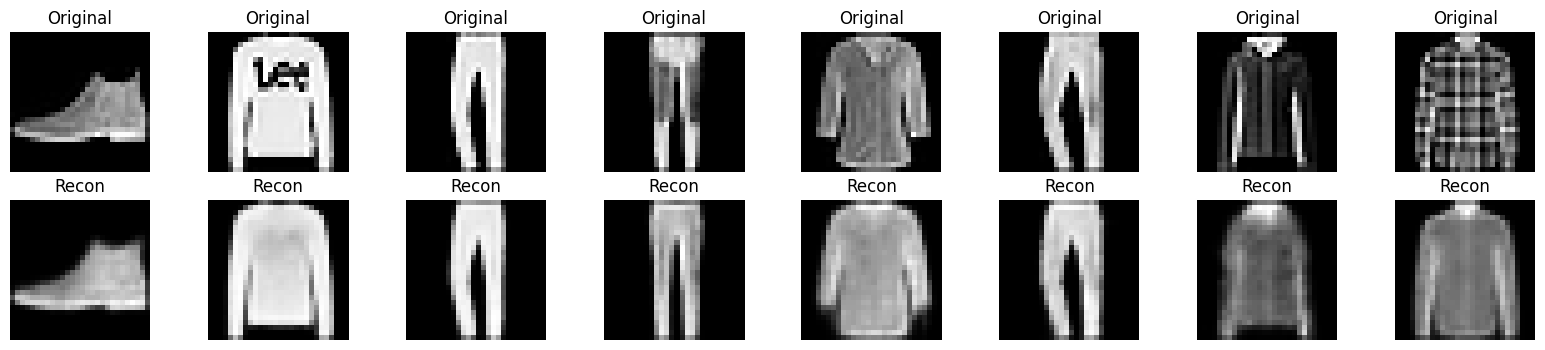

In [12]:
# --- 1. Plot Training Loss Components ---
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(15, 5))

# Plot Total Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_losses, label='Total Loss', color='blue')
plt.title('Total Training Loss')
plt.xlabel('Epoch')
plt.grid(True)

# Plot Reconstruction Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, recon_losses, label='Recon Loss (BCE)', color='orange')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.grid(True)

# Plot KL Divergence
plt.subplot(1, 3, 3)
plt.plot(epochs_range, kld_losses, label='KL Divergence', color='green')
plt.title('KL Divergence')
plt.xlabel('Epoch')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 2. Visualize Reconstructions (Original vs Reconstructed) ---
vae.eval()
with torch.no_grad():
    # Get a batch of test data
    data, _ = next(iter(test_loader))
    data = data.to(device)
    
    # Reconstruct
    recon, _, _ = vae(data)
    
    # Move to CPU for plotting
    data = data.cpu()
    recon = recon.cpu()
    
    # Plot side-by-side
    n = 8  # How many items to display
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Display original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].permute(1, 2, 0).squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis("off")
        
        # Display reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i].permute(1, 2, 0).squeeze(), cmap='gray')
        plt.title("Recon")
        plt.axis("off")
    plt.show()

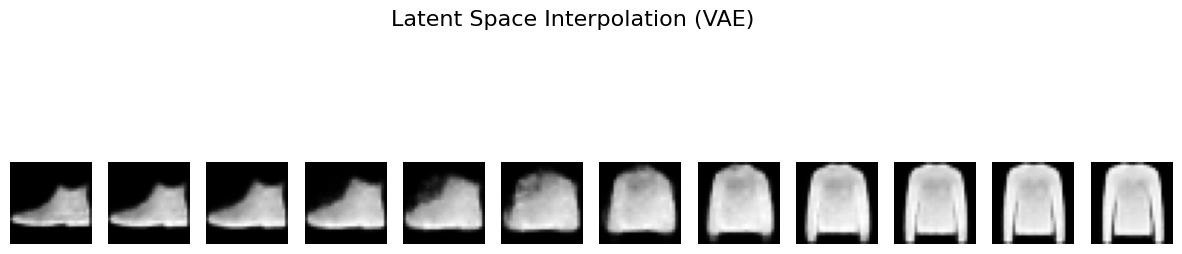

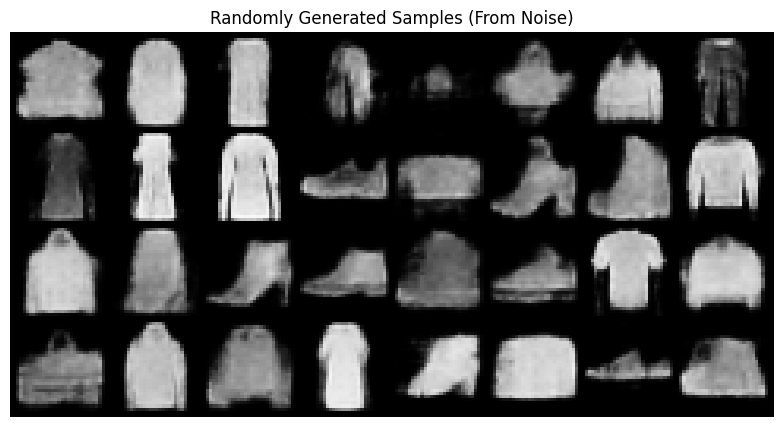

In [13]:
# Function to interpolate between two vectors
def interpolate_points(p1, p2, n_steps=10):
    # Create n_steps linearly spaced vectors between p1 and p2
    ratios = np.linspace(0, 1, n_steps)
    vectors = []
    for ratio in ratios:
        v = (1.0 - ratio) * p1 + ratio * p2
        vectors.append(v)
    return torch.stack(vectors)

vae.eval()

# --- Task 1: Interpolation (Morphing) ---
# Get two images from test set (e.g., Ankle boot and Pullover)
data, _ = next(iter(test_loader))
data = data.to(device)
img1 = data[0] # First image
img2 = data[1] # Second image

# Encode them to get their latent vectors
with torch.no_grad():
    _, mu1, _ = vae(img1.unsqueeze(0))
    _, mu2, _ = vae(img2.unsqueeze(0))
    
    # CRITICAL FIX: Squeeze to remove batch dim [1, 20] -> [20]
    # This prevents the "Unflatten" error you saw earlier
    mu1 = mu1.squeeze(0)
    mu2 = mu2.squeeze(0)

# Create 12 interpolated vectors between the two points
z_interp = interpolate_points(mu1, mu2, n_steps=12).to(device)

# Decode the interpolated vectors
with torch.no_grad():
    generated_imgs = vae.decoder(vae.decoder_input(z_interp))
    generated_imgs = generated_imgs.cpu()

# Plot Interpolation
plt.figure(figsize=(15, 4))
plt.suptitle("Latent Space Interpolation (VAE)", fontsize=16)
for i in range(12):
    ax = plt.subplot(1, 12, i + 1)
    plt.imshow(generated_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

# --- Task 2: Random Generation (From Noise) ---
# Sample from Standard Normal Distribution N(0, 1)
z_random = torch.randn(32, LATENT_DIM).to(device)

with torch.no_grad():
    random_imgs = vae.decoder(vae.decoder_input(z_random))
    random_imgs = random_imgs.cpu()

# Plot Random Generation
grid = torchvision.utils.make_grid(random_imgs, nrow=8)
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title("Randomly Generated Samples (From Noise)")
plt.show()

In [14]:
# Cell 8: GAN Architecture (DCGAN)

# Hyperparameters
nz = 100    # Size of z latent vector (standard for GANs)
ngf = 64    # Size of feature maps in generator
ndf = 64    # Size of feature maps in discriminator

# Custom weights initialization called on netG and netD
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# --- GENERATOR ---
# Input: (N, nz, 1, 1) -> Output: (N, 1, 28, 28)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z, going into a convolution
            # We treat Z as a 1x1 image with 'nz' channels
            nn.ConvTranspose2d(nz, ngf * 4, 3, 1, 0, bias=False), # -> (ngf*4) x 3 x 3
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 3, 2, 0, bias=False), # -> (ngf*2) x 7 x 7
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False), # -> (ngf) x 14 x 14
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf, 1, 4, 2, 1, bias=False), # -> 1 x 28 x 28
            nn.Tanh() # Output range [-1, 1] - CRITICAL for GANs
        )

    def forward(self, input):
        return self.main(input)

# --- DISCRIMINATOR ---
# Input: (N, 1, 28, 28) -> Output: (N, 1) (Probability Real)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is 1 x 28 x 28
            nn.Conv2d(1, ndf, 4, 2, 1, bias=False), # -> ndf x 14 x 14
            nn.LeakyReLU(0.2, inplace=True), # LeakyReLU is crucial for GANs!
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False), # -> (ndf*2) x 7 x 7
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 0, bias=False), # -> (ndf*4) x 3 x 3
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 4, 1, 3, 1, 0, bias=False), # -> 1 x 1 x 1
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# Initialize Models
netG = Generator().to(device)
netD = Discriminator().to(device)

# Apply weights
netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2),

In [15]:
# Cell 9: GAN Data Loading (Renormalization)

# Define Transform: ToTensor gives [0, 1], Normalize((0.5,), (0.5,)) shifts to [-1, 1]
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

# Create new dataset and loader
train_dataset_gan = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform_gan, download=True
)

gan_loader = DataLoader(train_dataset_gan, batch_size=BATCH_SIZE, shuffle=True)

# Verify the range is correct
real_batch, _ = next(iter(gan_loader))
print(f"New Data Range -> Min: {real_batch.min():.2f}, Max: {real_batch.max():.2f}")
# Expected: Min approx -1.0, Max approx 1.0

New Data Range -> Min: -1.00, Max: 1.00


In [16]:
# Cell 10: GAN Training Loop

# 1. Setup Loss and Optimizers
criterion = nn.BCELoss()

# Fixed noise to visualize progress consistently
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Optimizers - Adam with Beta1 = 0.5 is standard for DCGAN
lr_gan = 0.0002
beta1 = 0.5
optimizerD = torch.optim.Adam(netD.parameters(), lr=lr_gan, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr_gan, betas=(beta1, 0.999))

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0
num_epochs_gan = 20  # PDF suggests monitoring evolution

print("Starting GAN Training Loop...")

for epoch in range(num_epochs_gan):
    for i, data in enumerate(gan_loader, 0):
        
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ############################
        netD.zero_grad()
        
        # -- Train with Real Batch --
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1., dtype=torch.float, device=device) # Real label = 1
        
        output = netD(real_cpu)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # -- Train with Fake Batch --
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.) # Fake label = 0
        
        # Detach fake to avoid calculating gradients for G during D update
        output = netD(fake.detach()) 
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        
        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ############################
        netG.zero_grad()
        label.fill_(1.)  # Generator wants D to think these are real (Label=1)
        
        output = netD(fake) # Re-use fake batch, but now gradients flow to G
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        
        optimizerG.step()

        # Save Losses
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Print stats every 200 batches
        if i % 200 == 0:
            print(f'[{epoch}/{num_epochs_gan}][{i}/{len(gan_loader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

    # Save a checkup image every epoch
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    img_list.append(torchvision.utils.make_grid(fake, padding=2, normalize=True))

print("GAN Training Complete!")

Starting GAN Training Loop...
[0/20][0/469] Loss_D: 1.4493 Loss_G: 1.1836 D(x): 0.5922 D(G(z)): 0.5632 / 0.3370
[0/20][200/469] Loss_D: 0.2544 Loss_G: 3.8101 D(x): 0.9257 D(G(z)): 0.1500 / 0.0302
[0/20][400/469] Loss_D: 0.2215 Loss_G: 3.0982 D(x): 0.9109 D(G(z)): 0.1076 / 0.0626
[1/20][0/469] Loss_D: 0.2871 Loss_G: 3.2278 D(x): 0.9236 D(G(z)): 0.1697 / 0.0532
[1/20][200/469] Loss_D: 0.6570 Loss_G: 3.8788 D(x): 0.9469 D(G(z)): 0.4141 / 0.0306
[1/20][400/469] Loss_D: 0.5081 Loss_G: 2.3930 D(x): 0.7982 D(G(z)): 0.2104 / 0.1259
[2/20][0/469] Loss_D: 0.5249 Loss_G: 2.1044 D(x): 0.7481 D(G(z)): 0.1638 / 0.1634
[2/20][200/469] Loss_D: 0.6996 Loss_G: 1.8409 D(x): 0.6987 D(G(z)): 0.2350 / 0.1932
[2/20][400/469] Loss_D: 0.6728 Loss_G: 2.0717 D(x): 0.7864 D(G(z)): 0.3121 / 0.1542
[3/20][0/469] Loss_D: 0.6648 Loss_G: 2.6458 D(x): 0.8658 D(G(z)): 0.3661 / 0.0940
[3/20][200/469] Loss_D: 0.6626 Loss_G: 1.7166 D(x): 0.6374 D(G(z)): 0.1238 / 0.2442
[3/20][400/469] Loss_D: 0.6318 Loss_G: 1.7013 D(x): 0.

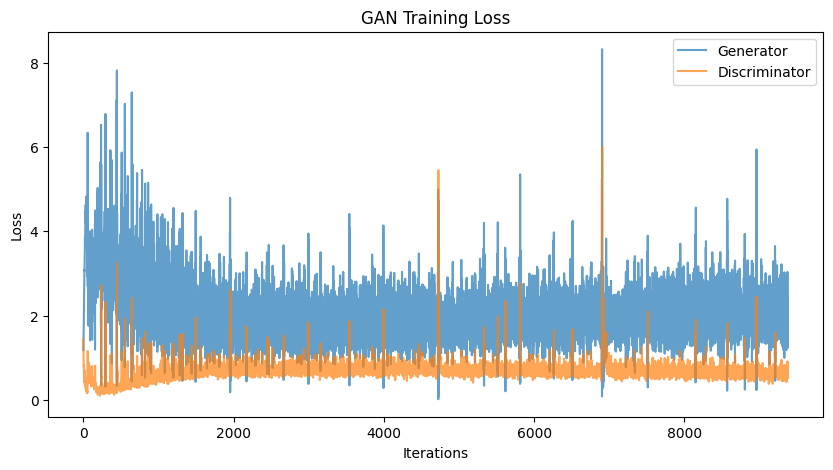

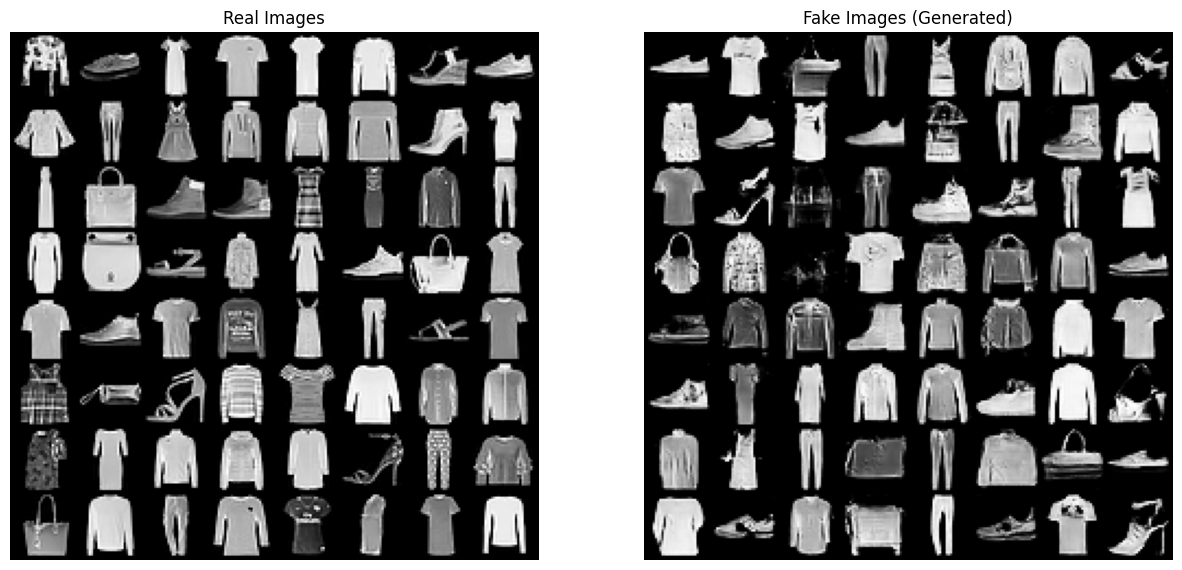

In [17]:
# Cell 11: GAN Evaluation

# 1. Plot GAN Losses
plt.figure(figsize=(10, 5))
plt.title("GAN Training Loss")
plt.plot(G_losses, label="Generator", alpha=0.7)
plt.plot(D_losses, label="Discriminator", alpha=0.7)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 2. Visualize Real vs. Generated Images
# Grab a batch of real images
real_batch = next(iter(gan_loader))

# Plot Side-by-Side
plt.figure(figsize=(15, 8))

# Real Images
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(torchvision.utils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))

# Fake Images (from the last epoch)
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images (Generated)")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

Starting GAN Training with Label Smoothing...
Epoch 1 Completed.
Epoch 2 Completed.
Epoch 3 Completed.
Epoch 4 Completed.
Epoch 5 Completed.


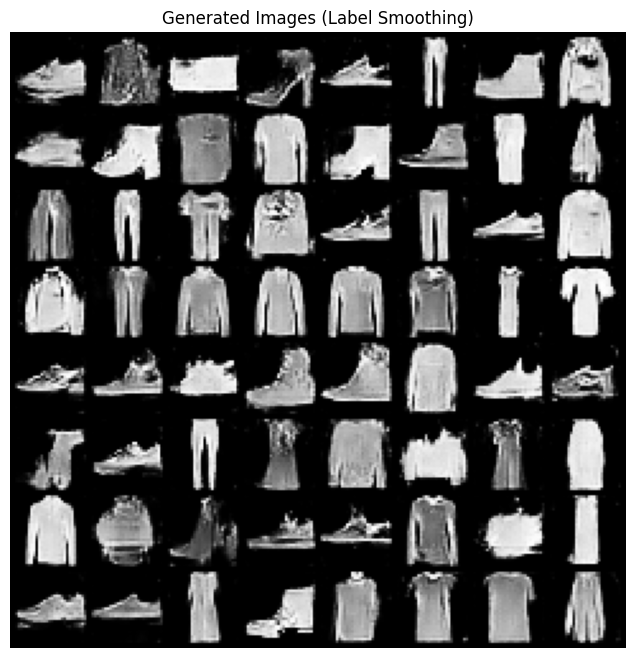

In [18]:
# Cell 12: GAN Improvement (Label Smoothing)

# Re-initialize models to start fresh
netG_smooth = Generator().to(device)
netD_smooth = Discriminator().to(device)
netG_smooth.apply(weights_init)
netD_smooth.apply(weights_init)

optimizerD_smooth = torch.optim.Adam(netD_smooth.parameters(), lr=lr_gan, betas=(beta1, 0.999))
optimizerG_smooth = torch.optim.Adam(netG_smooth.parameters(), lr=lr_gan, betas=(beta1, 0.999))

print("Starting GAN Training with Label Smoothing...")
smoothing_value = 0.9

for epoch in range(5): # Run shorter for demonstration
    for i, data in enumerate(gan_loader, 0):
        
        # (1) Update D
        netD_smooth.zero_grad()
        
        # Real Batch with SMOOTHED Labels
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        # TRICK: Use 0.9 instead of 1.0
        label = torch.full((b_size,), smoothing_value, dtype=torch.float, device=device)
        
        output = netD_smooth(real_cpu)
        errD_real = criterion(output, label)
        errD_real.backward()
        
        # Fake Batch (Labels stay 0)
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG_smooth(noise)
        label.fill_(0.)
        
        output = netD_smooth(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD_smooth.step()

        # (2) Update G
        netG_smooth.zero_grad()
        label.fill_(1.) # Generator still aims for 1.0
        output = netD_smooth(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG_smooth.step()
        
    print(f'Epoch {epoch+1} Completed.')

# Visualize Result
with torch.no_grad():
    fake_smooth = netG_smooth(fixed_noise).detach().cpu()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images (Label Smoothing)")
plt.imshow(np.transpose(torchvision.utils.make_grid(fake_smooth, padding=2, normalize=True), (1,2,0)))
plt.show()

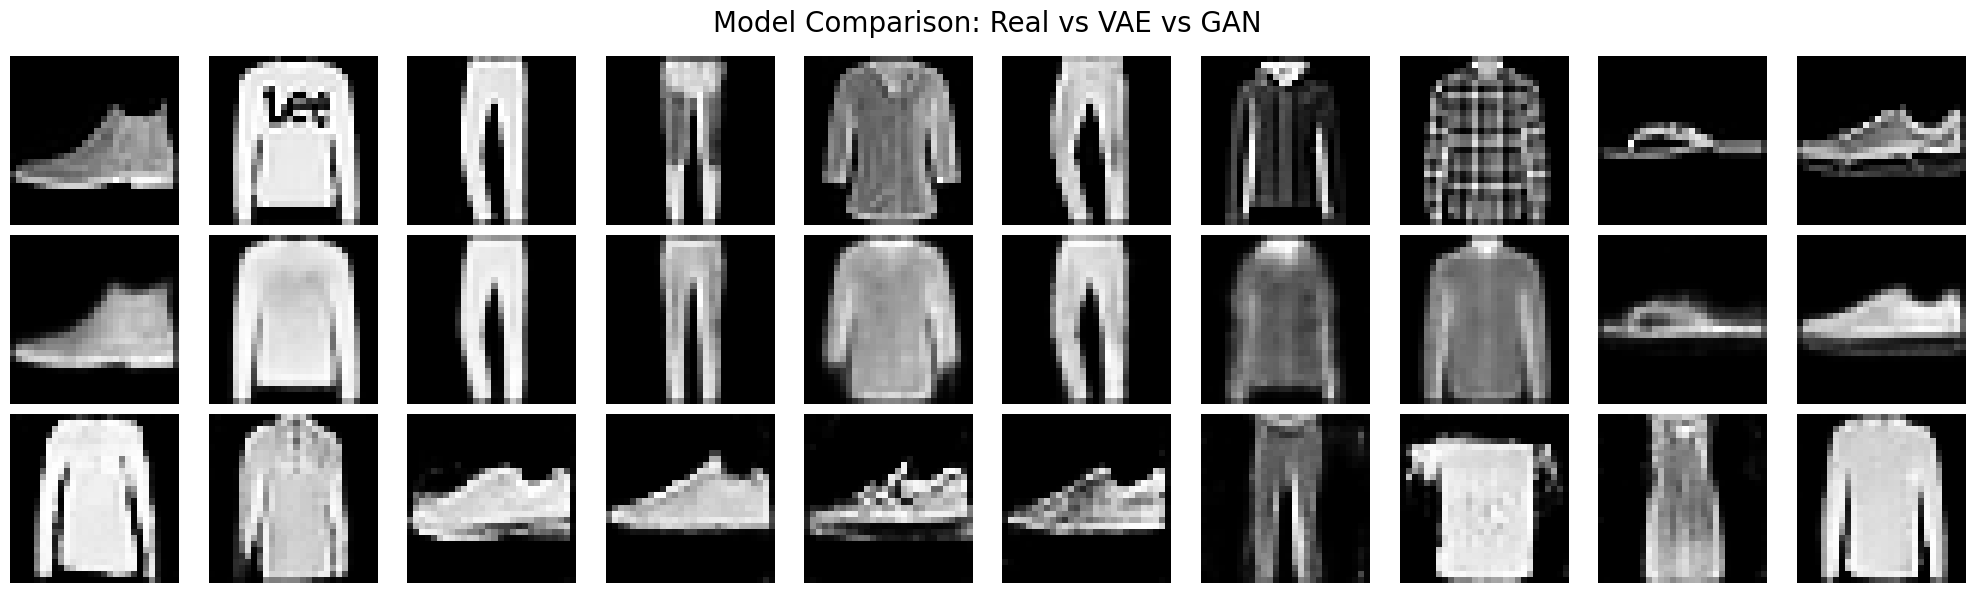

In [19]:
# Cell 13: Final Side-by-Side Comparison (Real vs VAE vs GAN)

# 1. Setup
n_samples = 10
plt.figure(figsize=(20, 6))

# --- Row 1: Real Images ---
# Get a batch of test data
data, _ = next(iter(test_loader))
real_samples = data[:n_samples].to(device)

# --- Row 2: VAE Reconstructions ---
vae.eval()
with torch.no_grad():
    vae_recon, _, _ = vae(real_samples)

# --- Row 3: GAN Generations ---
# Since GAN is unconditional, we generate random samples
# We generate a few extra and pick the first n_samples
noise = torch.randn(n_samples, nz, 1, 1, device=device)
with torch.no_grad():
    gan_samples = netG_smooth(noise) # Use the improved generator

# Helper function to process tensors for display
def to_display(tensor):
    tensor = tensor.cpu().detach()
    # If range is [-1, 1] (GAN), convert to [0, 1]
    if tensor.min() < 0:
        tensor = (tensor + 1) / 2
    return tensor.permute(0, 2, 3, 1).numpy() # (N, H, W, C)

# Process images
real_display = to_display(real_samples)
vae_display = to_display(vae_recon)
gan_display = to_display(gan_samples)

# --- Plotting ---
for i in range(n_samples):
    # Real
    ax = plt.subplot(3, n_samples, i + 1)
    plt.imshow(real_display[i].squeeze(), cmap='gray')
    if i == 0: ax.set_ylabel("Real", fontsize=15, fontweight='bold')
    plt.axis('off')

    # VAE
    ax = plt.subplot(3, n_samples, i + 1 + n_samples)
    plt.imshow(vae_display[i].squeeze(), cmap='gray')
    if i == 0: ax.set_ylabel("VAE (Recon)", fontsize=15, fontweight='bold')
    plt.axis('off')

    # GAN
    ax = plt.subplot(3, n_samples, i + 1 + 2*n_samples)
    plt.imshow(gan_display[i].squeeze(), cmap='gray')
    if i == 0: ax.set_ylabel("GAN (Random)", fontsize=15, fontweight='bold')
    plt.axis('off')

plt.suptitle("Model Comparison: Real vs VAE vs GAN", fontsize=20)
plt.tight_layout()
plt.show()

Calculating final metrics...

=== Final Model Performance Metrics ===


,Model,Metric,Value,Interpretation
0,VAE,Reconstruction Loss (BCE),218.3623,Lower is better (less blur)
1,VAE,KL Divergence,17.8089,~15-20 is healthy (good latent structure)
2,GAN,Discriminator Real Score D(x),0.4853,Closer to 0.5 means D is confused (Good Genera...
3,GAN,Discriminator Fake Score D(G(z)),0.2415,Closer to 0.5 means G fooled D (Good Generator)


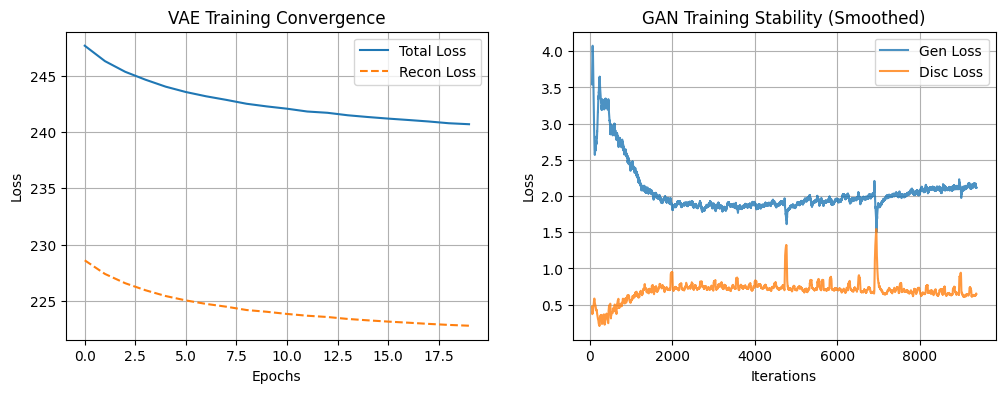

In [22]:
import pandas as pd
import torch.nn.functional as F

# --- 1. Evaluate VAE on Test Set ---
def evaluate_vae(model, loader):
    model.eval()
    total_recon_loss = 0
    total_kld_loss = 0
    criterion = nn.BCELoss(reduction='sum')
    
    with torch.no_grad():
        for data, _ in loader:
            data = data.to(device)
            recon, mu, logvar = model(data)
            
            # Reconstruction (BCE)
            bce = criterion(recon, data)
            # KL Divergence
            kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            
            total_recon_loss += bce.item()
            total_kld_loss += kld.item()
            
    avg_recon = total_recon_loss / len(loader.dataset)
    avg_kld = total_kld_loss / len(loader.dataset)
    return avg_recon, avg_kld

# --- 2. Evaluate GAN on Test Set ---
def evaluate_gan(netG, netD, loader):
    netG.eval()
    netD.eval()
    
    real_scores = []
    fake_scores = []
    
    with torch.no_grad():
        for data, _ in loader:
            # Real Images
            real_imgs = data.to(device)
            output_real = netD(real_imgs)
            real_scores.append(output_real.mean().item())
            
            # Fake Images
            noise = torch.randn(real_imgs.size(0), nz, 1, 1, device=device)
            fake_imgs = netG(noise)
            output_fake = netD(fake_imgs)
            fake_scores.append(output_fake.mean().item())
            
    avg_real_score = sum(real_scores) / len(real_scores) # D(x)
    avg_fake_score = sum(fake_scores) / len(fake_scores) # D(G(z))
    
    return avg_real_score, avg_fake_score

# --- 3. Run Evaluations ---
print("Calculating final metrics...")

# VAE Metrics (Using the VAE Test Loader [0,1])
vae_recon, vae_kld = evaluate_vae(vae, test_loader)

# GAN Metrics (Using the GAN Loader [-1,1])
# We use a subset of the GAN loader as a 'test' proxy since we didn't make a specific GAN test loader
gan_real_score, gan_fake_score = evaluate_gan(netG_smooth, netD_smooth, gan_loader)

# --- 4. Create Summary Table ---
metrics_data = {
    "Model": ["VAE", "VAE", "GAN", "GAN"],
    "Metric": ["Reconstruction Loss (BCE)", "KL Divergence", "Discriminator Real Score D(x)", "Discriminator Fake Score D(G(z))"],
    "Value": [f"{vae_recon:.4f}", f"{vae_kld:.4f}", f"{gan_real_score:.4f}", f"{gan_fake_score:.4f}"],
    "Interpretation": [
        "Lower is better (less blur)", 
        "~15-20 is healthy (good latent structure)", 
        "Closer to 0.5 means D is confused (Good Generator)", 
        "Closer to 0.5 means G fooled D (Good Generator)"
    ]
}

df = pd.DataFrame(metrics_data)

# Display the table
print("\n=== Final Model Performance Metrics ===")
display(df)

# --- 5. (Optional) Plot Training History Recap ---
plt.figure(figsize=(12, 4))

# VAE History
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Total Loss")
plt.plot(recon_losses, label="Recon Loss", linestyle='--')
plt.title("VAE Training Convergence")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# GAN History (Smoothed for readability)
plt.subplot(1, 2, 2)
plt.plot(pd.Series(G_losses).rolling(50).mean(), label="Gen Loss", alpha=0.8)
plt.plot(pd.Series(D_losses).rolling(50).mean(), label="Disc Loss", alpha=0.8)
plt.title("GAN Training Stability (Smoothed)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()